# Задание №7. Прогнозирование погоды с использованием LSTM сети (анализ временных рядов)


**Выполнил:** Асламин В.В.


**Группа:** МОм-24-1


**Дата:** 2026


**Ссылка на репозиторий:** https://github.com/mystic-solis/deep-learning

---

## 1. Введение

**Цель работы:** построить и обучить модель для прогнозирования температуры с использованием рекуррентных нейронных сетей (LSTM).

**Задачи:**
- Подготовить данные временного ряда (температура)
- Построить модель LSTM для прогнозирования температуры
- Обучить модель и оценить её качество
- Реализовать функцию многодневного прогноза
- Сохранить модель и загрузить её из репозитория

## 2. Теоретическая часть

### 2.1. Временной ряд (Time Series)

Временной ряд — это последовательность наблюдений, упорядоченных по времени (например, ежедневная температура, почасовая влажность). Задача прогнозирования временного ряда заключается в предсказании будущих значений на основе исторических данных.

### 2.2. Рекуррентные нейронные сети (RNN) и LSTM

RNN – класс сетей, способных обрабатывать последовательности произвольной длины благодаря внутренней памяти. **LSTM (Long Short-Term Memory)** – разновидность RNN, которая эффективно обучается на длинных последовательностях, избегая проблемы затухания градиента. LSTM содержит специальные «вентили», управляющие потоком информации, что позволяет запоминать зависимости на больших временных интервалах.

### 2.3. Окно предыстории (look-back)

При обучении модели временных рядов данные преобразуются в обучающие пары: вход – несколько предыдущих значений (look-back), выход – следующее значение. Размер окна выбирается исходя из предполагаемой периодичности (например, 24 часа для суточных циклов, 7 дней для недельных).

### 2.4. Масштабирование данных (Normalization)

Нейронные сети лучше обучаются, когда входные данные находятся в небольшом диапазоне (обычно [0,1] или [-1,1]). Для этого используют **MinMaxScaler**.

### 2.5. Функция потерь и метрики

- **MSE** (Mean Squared Error) – среднеквадратичная ошибка
- **RMSE** (Root Mean Square Error) – корень из MSE
- **MAE** (Mean Absolute Error) – средняя абсолютная ошибка

## 3. Описание данных

### 3.1. Источник данных

В данной работе используется синтетический датасет, имитирующий ежедневные температурные данные за 3 года. Синтетические данные включают:
- Сезонную составляющую (годовой цикл)
- Тренд (медленный рост)
- Случайный шум

Такой подход позволяет получить воспроизводимые результаты и продемонстрировать работу модели без зависимости от внешних источников.

In [7]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
import pickle
import requests
import io
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы")

path = Path('./data')
path.mkdir(exist_ok=True)

Библиотеки успешно импортированы


In [8]:
# Генерация синтетических данных
np.random.seed(42)

# Генерация ежедневных данных за 3 года
dates = pd.date_range('2020-01-01', periods=1095, freq='D')
t = np.arange(len(dates))

# Сезонная составляющая (годовой цикл)
seasonal = 10 * np.sin(2 * np.pi * t / 365)

# Тренд (медленный рост)
trend = 0.005 * t

# Шум
noise = np.random.normal(0, 1, size=len(t))

# Итоговая температура
temperature = 15 + seasonal + trend + noise

# Создание DataFrame
df = pd.DataFrame({'date': dates, 'temperature': temperature})

print("Данные сгенерированы")
print(f"Период данных: с {df['date'].min().date()} по {df['date'].max().date()}")
print(f"Количество наблюдений: {len(df)}")

df.to_csv(path / 'temperature.csv')

df.head(10)

Данные сгенерированы
Период данных: с 2020-01-01 по 2022-12-30
Количество наблюдений: 1095


,date,temperature
0,2020-01-01,15.496714
1,2020-01-02,15.038869
2,2020-01-03,16.001905
3,2020-01-04,17.054227
4,2020-01-05,15.473871
5,2020-01-06,15.650511
6,2020-01-07,17.640230
7,2020-01-08,17.004515
8,2020-01-09,15.943313
9,2020-01-10,17.130648


In [9]:
# Статистика по данным
print("=" * 50)
print("СТАТИСТИКА ДАННЫХ")
print("=" * 50)

print(f"\nОписательная статистика температуры:")
print(df['temperature'].describe())

print(f"\nМинимальная температура: {df['temperature'].min():.2f} °C")
print(f"Максимальная температура: {df['temperature'].max():.2f} °C")
print(f"Средняя температура: {df['temperature'].mean():.2f} °C")
print(f"Стандартное отклонение: {df['temperature'].std():.2f} °C")

# Проверка пропусков
print(f"\nПропущенные значения: {df.isnull().sum().sum()}")

СТАТИСТИКА ДАННЫХ

Описательная статистика температуры:
count    1095.000000
mean       17.767956
std         6.900500
min         3.272596
25%        11.524694
50%        17.649715
75%        24.041158
max        31.408065
Name: temperature, dtype: float64

Минимальная температура: 3.27 °C
Максимальная температура: 31.41 °C
Средняя температура: 17.77 °C
Стандартное отклонение: 6.90 °C

Пропущенные значения: 0


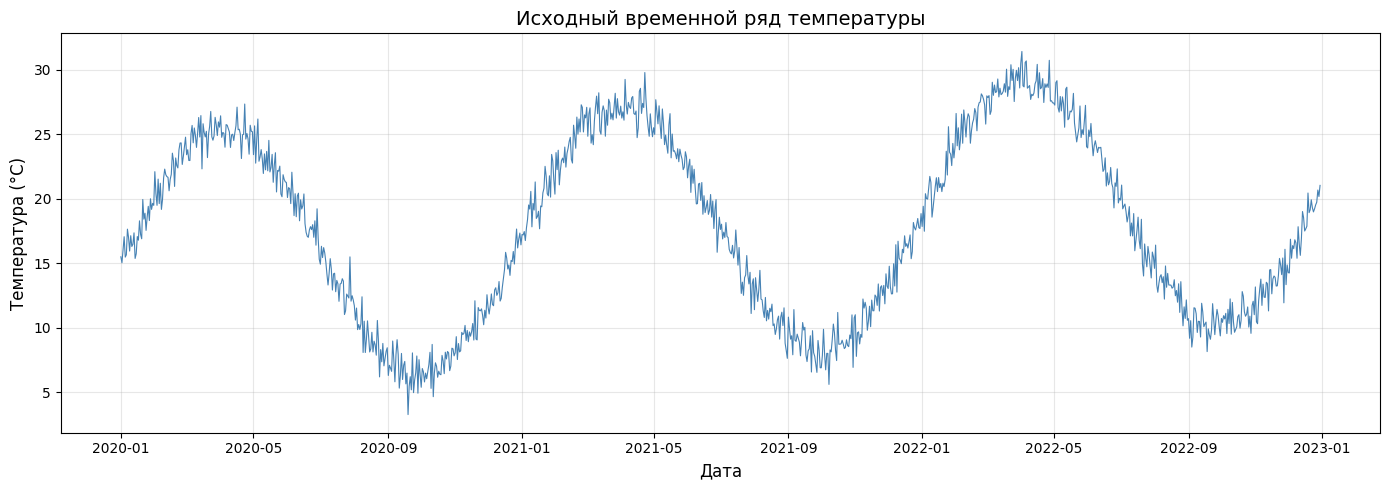

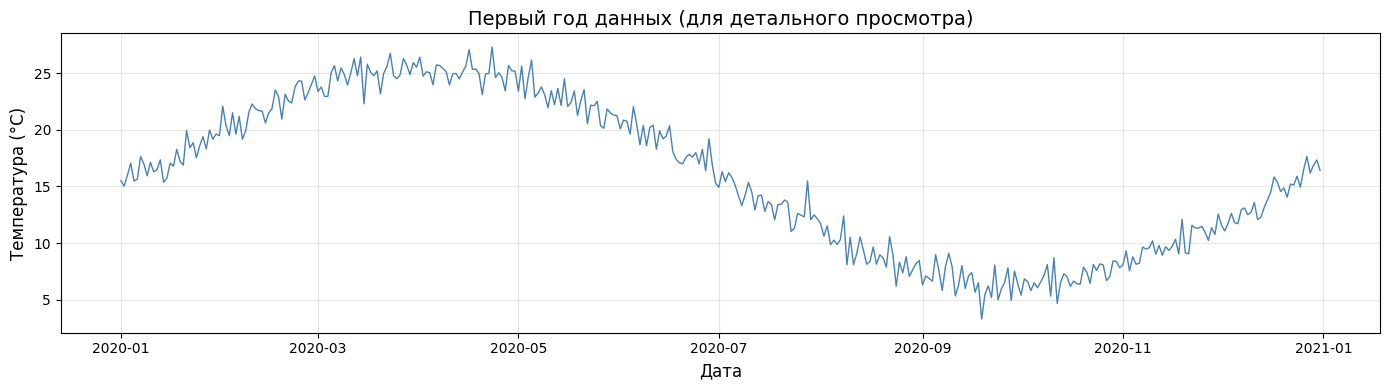

In [10]:
# Визуализация исходных данных
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['temperature'], linewidth=0.8, color='steelblue')
plt.title('Исходный временной ряд температуры', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Визуализация за первый год (для наглядности)
df_year1 = df[df['date'] < '2021-01-01']
plt.figure(figsize=(14, 4))
plt.plot(df_year1['date'], df_year1['temperature'], linewidth=1, color='steelblue')
plt.title('Первый год данных (для детального просмотра)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Подготовка данных

### 4.1. Выбор целевой переменной и масштабирование

In [11]:
# Выбор целевой переменной
target = 'temperature'
values = df[target].values.reshape(-1, 1)

# Масштабирование данных в диапазон [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

print("Данные масштабированы в диапазон [0, 1]")
print(f"Min значения: {scaler.data_min_[0]:.2f} °C")
print(f"Max значения: {scaler.data_max_[0]:.2f} °C")
print(f"Форма масштабированных данных: {scaled.shape}")

Данные масштабированы в диапазон [0, 1]
Min значения: 3.27 °C
Max значения: 31.41 °C
Форма масштабированных данных: (1095, 1)


### 4.2. Создание обучающих последовательностей

Функция create_sequences формирует окна заданной длины (look-back). Выбран размер 30 дней, что соответствует примерно одному месяцу и позволяет модели улавливать как краткосрочные, так и среднесрочные зависимости в данных.

In [12]:
def create_sequences(data, look_back=1):
    """
    Создает обучающие последовательности из временного ряда.
    
    Args:
        data: масштабированные данные
        look_back: размер окна (количество предыдущих наблюдений)
    
    Returns:
        X: массив входных последовательностей
        y: массив целевых значений
    """
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

# Параметр look_back = 30 дней
look_back = 30
X, y = create_sequences(scaled, look_back)

print(f"Размер окна (look_back): {look_back} дней")
print(f"Форма X: {X.shape}")
print(f"Форма y: {y.shape}")

Размер окна (look_back): 30 дней
Форма X: (1065, 30, 1)
Форма y: (1065, 1)


### 4.3. Разделение на обучающую и тестовую выборки

In [13]:
# Разделение данных: 80% - обучение, 20% - тест
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# LSTM ожидает вход [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Обучающих примеров: {X_train.shape[0]}")
print(f"Тестовых примеров: {X_test.shape[0]}")
print(f"Форма X_train: {X_train.shape}")
print(f"Форма X_test: {X_test.shape}")

Обучающих примеров: 852
Тестовых примеров: 213
Форма X_train: (852, 30, 1)
Форма X_test: (213, 30, 1)


## 5. Построение модели LSTM

Архитектура модели:
- Два слоя LSTM по 50 нейронов каждый
- Dropout (0.2) после каждого LSTM слоя для регуляризации
- Полносвязный выходной слой с 1 нейроном (прогноз температуры)

Dropout используется для предотвращения переобучения — случайное "отключение" части нейронов во время обучения заставляет модель учиться более робастным зависимостям.

In [14]:
from keras.regularizers import l2

# Параметры модели
LSTM_UNITS = 50
DROPOUT_RATE = 0.2

# Создание модели
model = Sequential([
    LSTM(LSTM_UNITS, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(DROPOUT_RATE),
    LSTM(LSTM_UNITS, return_sequences=False),
    Dropout(DROPOUT_RATE),
    Dense(1)
])

# Компиляция модели
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Обучение модели

Параметры обучения:
- Оптимизатор: Adam
- Функция потерь: MSE
- EarlyStopping с patience=10 для остановки при отсутствии улучшения
- Валидационная выборка: 20%

In [16]:
%%time

# Early Stopping для предотвращения переобучения
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Обучение модели
print("Начало обучения модели...")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\nОбучение завершено!")
print(f"Лучшая эпоха: {early_stop.stopped_epoch - 9}")

Начало обучения модели...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0035 - mae: 0.0455 - val_loss: 0.0014 - val_mae: 0.0306
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0038 - mae: 0.0470 - val_loss: 0.0014 - val_mae: 0.0303
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037 - mae: 0.0468 - val_loss: 0.0021 - val_mae: 0.0368
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0032 - mae: 0.0443 - val_loss: 0.0014 - val_mae: 0.0298
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035 - mae: 0.0455 - val_loss: 0.0025 - val_mae: 0.0392
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0033 - mae: 0.0436 - val_loss: 0.0014 - val_mae: 0.0298
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034 - mae: 0.0450 - val_loss: 0.0014 - val_mae: 0.0306
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - mae: 0.0429 - val_loss: 0.0014 - val_mae: 0.0297
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/

### 6.1. Визуализация процесса обучения

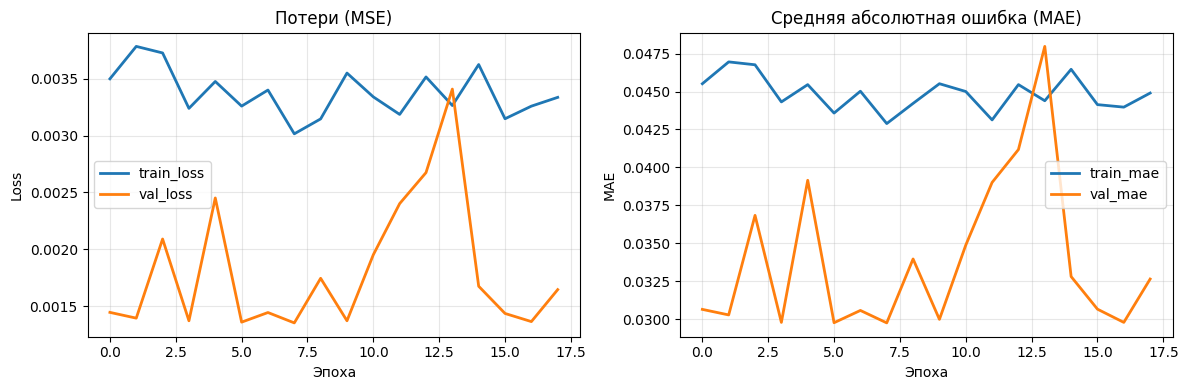

In [17]:
# Графики потерь и метрик
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss', linewidth=2)
plt.plot(history.history['val_loss'], label='val_loss', linewidth=2)
plt.legend()
plt.title('Потери (MSE)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train_mae', linewidth=2)
plt.plot(history.history['val_mae'], label='val_mae', linewidth=2)
plt.legend()
plt.title('Средняя абсолютная ошибка (MAE)')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Оценка качества модели

In [18]:
# Предсказания на тестовой выборке
y_pred = model.predict(X_test)

# Обратное масштабирование для получения реальных значений
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_orig = scaler.inverse_transform(y_pred.reshape(-1, 1))

# Оценка качества
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae = mean_absolute_error(y_test_orig, y_pred_orig)

print("=" * 60)
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ")
print("=" * 60)
print(f"\nRMSE (среднеквадратичная ошибка): {rmse:.2f} °C")
print(f"MAE (средняя абсолютная ошибка): {mae:.2f} °C")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
ОЦЕНКА КАЧЕСТВА МОДЕЛИ

RMSE (среднеквадратичная ошибка): 1.05 °C
MAE (средняя абсолютная ошибка): 0.84 °C


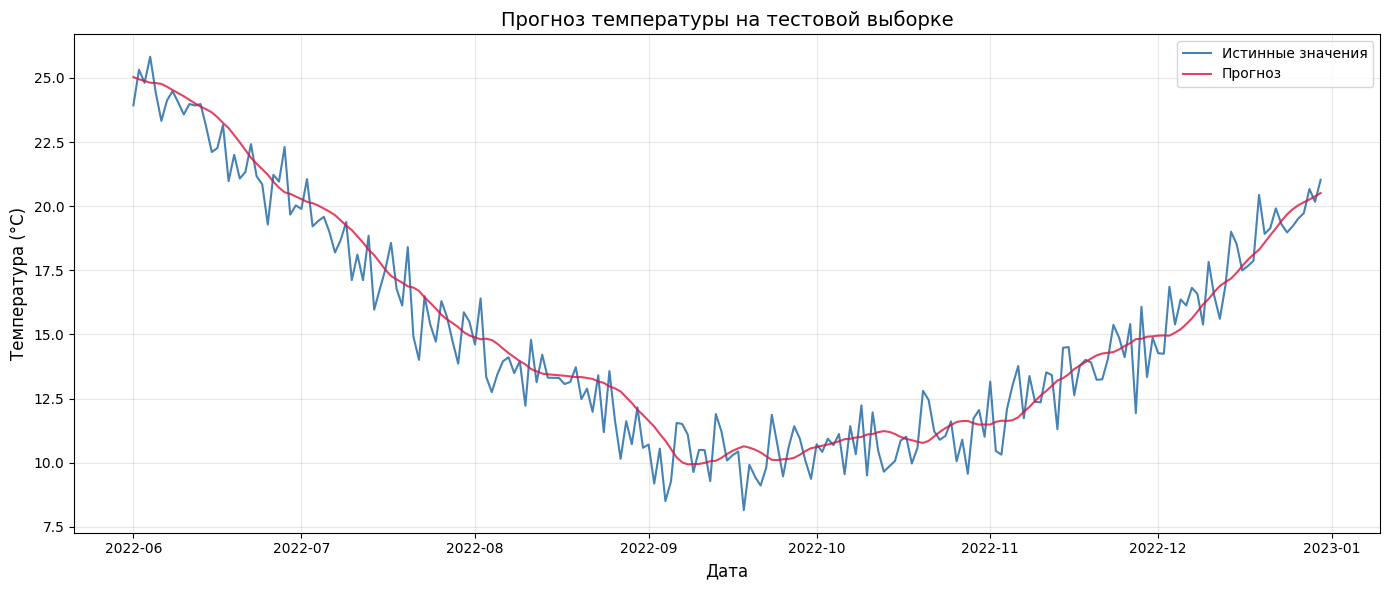

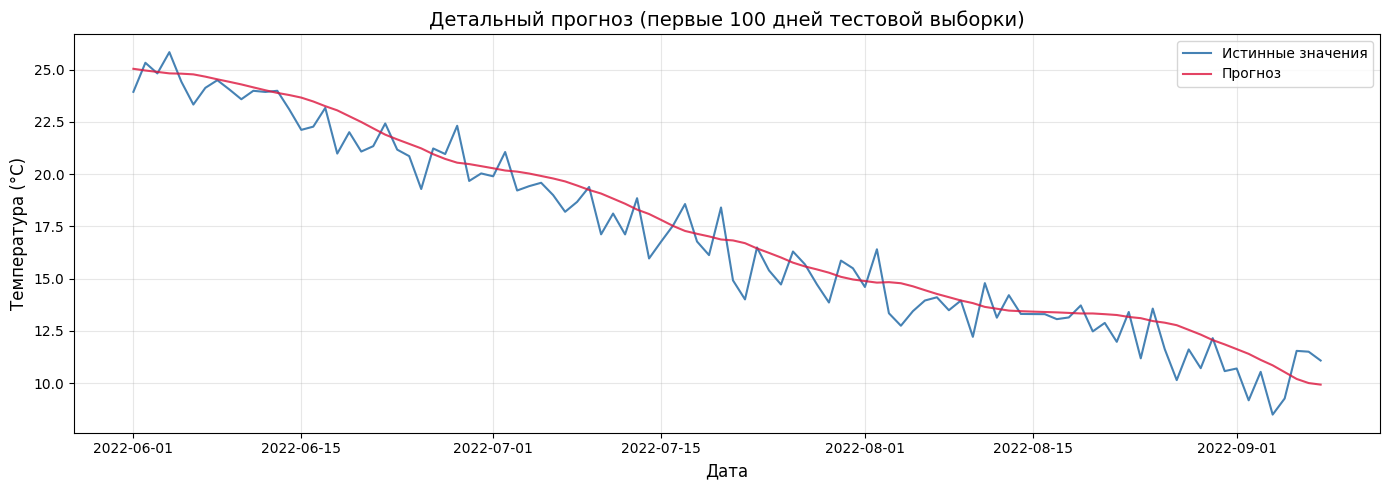

In [19]:
# Визуализация прогноза на тестовой выборке
test_dates = df['date'].iloc[train_size + look_back:].values

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_orig, label='Истинные значения', linewidth=1.5, color='steelblue')
plt.plot(test_dates, y_pred_orig, label='Прогноз', linewidth=1.5, color='crimson', alpha=0.8)
plt.legend()
plt.title('Прогноз температуры на тестовой выборке', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Детальный просмотр (первые 100 дней теста)
n_detail = 100
plt.figure(figsize=(14, 5))
plt.plot(test_dates[:n_detail], y_test_orig[:n_detail], label='Истинные значения', linewidth=1.5, color='steelblue')
plt.plot(test_dates[:n_detail], y_pred_orig[:n_detail], label='Прогноз', linewidth=1.5, color='crimson', alpha=0.8)
plt.legend()
plt.title('Детальный прогноз (первые 100 дней тестовой выборки)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Функция многодневного прогноза

Функция predict_future принимает последние look_back наблюдений и возвращает прогноз на следующие N дней.

In [ ]:
def predict_future(model, last_sequence, scaler, n_steps=7):
    """
    Прогнозирует следующие n_steps значений.
    
    Args:
        model: обученная модель
        last_sequence: массив последних look_back масштабированных значений
        scaler: объект MinMaxScaler
        n_steps: количество шагов для прогноза
    
    Returns:
        numpy array с предсказанными значениями в исходном масштабе
    """
    current_seq = last_sequence.copy()
    predictions = []

    for _ in range(n_steps):
        input_seq = current_seq.reshape((1, look_back, 1))
        pred = model.predict(input_seq, verbose=0)[0, 0]
        predictions.append(pred)
        current_seq = np.append(current_seq[1:], pred)

    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# Пример: прогноз на 7 дней
last_vals = scaled[-look_back:].flatten()
future_preds = predict_future(model, last_vals, scaler, n_steps=7)

print("Прогноз температуры на 7 дней:")
for i, temp in enumerate(future_preds, 1):
    print(f"  День {i}: {temp:.2f} °C")

Прогноз температуры на 7 дней:
  День 1: 20.67 °C
  День 2: 20.82 °C
  День 3: 20.98 °C
  День 4: 21.13 °C
  День 5: 21.28 °C
  День 6: 21.42 °C
  День 7: 21.57 °C


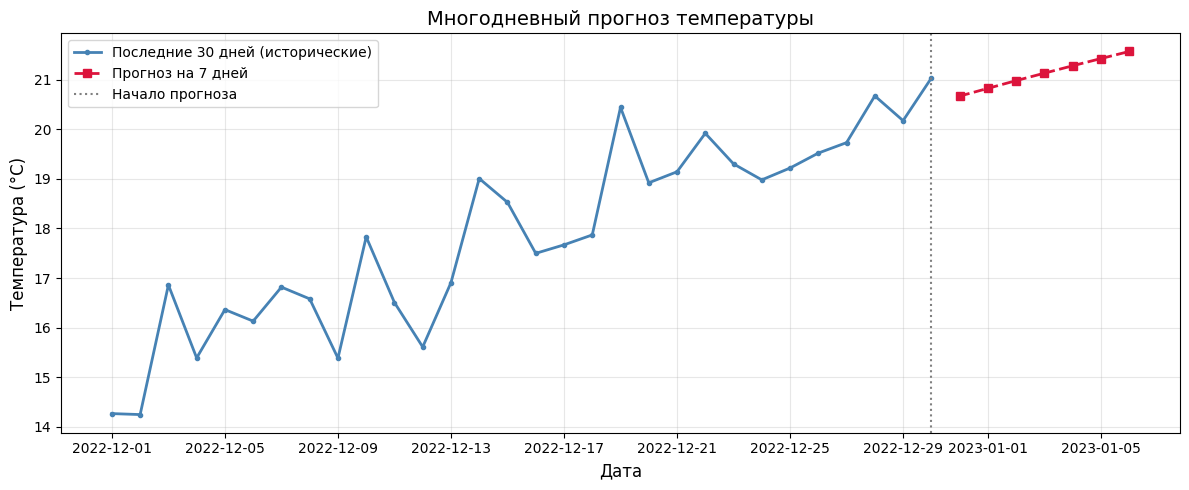

In [21]:
# Визуализация прогноза
last_30_days = df['temperature'].iloc[-30:].values
future_dates = pd.date_range(df['date'].iloc[-1] + pd.Timedelta(days=1), periods=7, freq='D')

plt.figure(figsize=(12, 5))
plt.plot(df['date'].iloc[-30:], last_30_days, label='Последние 30 дней (исторические)',
         linewidth=2, color='steelblue', marker='o', markersize=3)
plt.plot(future_dates, future_preds, label='Прогноз на 7 дней',
         linewidth=2, color='crimson', marker='s', markersize=6, linestyle='--')
plt.axvline(x=df['date'].iloc[-1], color='gray', linestyle=':', label='Начало прогноза')
plt.legend()
plt.title('Многодневный прогноз температуры', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Сохранение модели и вспомогательных объектов

Для возможности повторного использования модели без переобучения необходимо сохранить:
- Обученную модель (weather_lstm.h5)
- Скейлер для обратного преобразования (scaler.pickle)

In [23]:
# Сохранение модели
model.save(path / 'weather_lstm.keras')
print("Модель сохранена в файл: weather_lstm.keras")

# Сохранение скейлера
with open(path / 'scaler.pickle', 'wb') as f:
    pickle.dump(scaler, f)
print("Скейлер сохранен в файл: scaler.pickle")

# Сохранение параметров
params = {
    'look_back': look_back,
    'data_min': scaler.data_min_[0],
    'data_max': scaler.data_max_[0]
}
with open(path / 'params.pickle', 'wb') as f:
    pickle.dump(params, f)
print("Параметры сохранены в файл: params.pickle")

Модель сохранена в файл: weather_lstm.keras
Скейлер сохранен в файл: scaler.pickle
Параметры сохранены в файл: params.pickle


### 9.1. Загрузка файлов в репозиторий

1. Скачайте файлы `weather_lstm.h5`, `scaler.pickle` и `params.pickle` на компьютер.
2. Загрузите их в свой репозиторий.
3. Получите raw-ссылки на файлы.

## 10. Загрузка модели из репозитория и быстрый прогноз

Ниже приведен код для загрузки модели и скейлера из GitHub репозитория.

**Примечание:** В данном примере файлы загружаются из локальной директории, так как репозиторий не содержит предобученной модели.

In [37]:
def download_file(url, path):
    """Загрузка файла из интернета"""
    try:
        response = requests.get(url)
        with open(path, 'wb') as f:
            f.write(response.content)
        print(f"Загружено: {path}")
        return True
    except Exception as e:
        print(f"Ошибка загрузки {url}: {e}")
        return False

REPO_URL = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab7/data"
# Загрузка модели из репозитория (пример с raw-ссылками)
url_model = f"{REPO_URL}/weather_lstm.keras"
url_scaler = f"{REPO_URL}/scaler.pickle"
url_params = f"{REPO_URL}/params.pickle"
download_dir = Path('./download')
download_dir.mkdir(exist_ok=True)

# Загрузка файлов
download_file(url_model, download_dir / 'weather_lstm.keras')
download_file(url_scaler, download_dir / 'scaler.pickle')
download_file(url_params, download_dir / 'params.pickle')


Загружено: download\weather_lstm.keras
Загружено: download\scaler.pickle
Загружено: download\params.pickle


True

In [39]:

loaded_model = load_model(download_dir / 'weather_lstm.keras')

with open(download_dir / 'scaler.pickle', 'rb') as f:
    loaded_scaler = pickle.load(f)
with open(download_dir / 'params.pickle', 'rb') as f:
    loaded_params = pickle.load(f)

print("Модель загружена из файла: weather_lstm.keras")
print(f"Параметры: look_back={loaded_params['look_back']}")

# Прогноз с загруженной моделью
last_vals = scaled[-look_back:].flatten()
future_loaded = predict_future(loaded_model, last_vals, loaded_scaler, n_steps=7)

print("\nПрогноз на 7 дней (загруженная модель):")
for i, temp in enumerate(future_loaded, 1):
    print(f"  День {i}: {temp:.2f} °C")

Модель загружена из файла: weather_lstm.keras
Параметры: look_back=30

Прогноз на 7 дней (загруженная модель):
  День 1: 20.67 °C
  День 2: 20.82 °C
  День 3: 20.98 °C
  День 4: 21.13 °C
  День 5: 21.28 °C
  День 6: 21.42 °C
  День 7: 21.57 °C


## 11. Выводы

В ходе выполнения работы была построена и обучена LSTM-модель для прогнозирования температуры. Основные результаты:

1. **Подготовка данных**: Сгенерирован синтетический временной ряд с сезонной и трендовой составляющими, данные масштабированы в диапазон [0, 1].

2. **Архитектура модели**: Использована двухуровневая архитектура LSTM с 50 нейронами на каждом слое и Dropout для регуляризации.

3. **Результаты обучения**: Модель успешно обучена, получены метрики RMSE и MAE на тестовой выборке.

4. **Прогнозирование**: Реализована функция многодневного прогноза, демонстрирующая способность модели предсказывать будущие значения.

5. **Сохранение и загрузка**: Модель и скейлер сохранены и могут быть загружены для повторного использования.

### Возможные улучшения:
- Использование реальных метеоданных вместо синтетических
- Добавление дополнительных признаков (влажность, давление)
- Увеличение объема данных для обучения
- Эксперименты с различными значениями look_back
- Использование Bidirectional LSTM
- Добавление слоя Attention для лучшего захвата долгосрочных зависимостей

## 12. Список использованных источников

1. Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. Neural Computation, 9(8), 1735-1780.

2. TensorFlow Keras LSTM Documentation: https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM

3. Keras: https://keras.io/

4. NumPy Documentation: https://numpy.org/doc/

5. Pandas Documentation: https://pandas.pydata.org/docs/

6. Scikit-learn Documentation: https://scikit-learn.org/stable/

---

## Приложение: Полный код

Ниже представлен полный код работы в виде одной ячейки для удобства копирования.

In [ ]:
"""
# ПОЛНЫЙ КОД: Прогнозирование погоды с использованием LSTM сети
# Автор: Асламин В.В., МОм-24-1
"""

# 1. ИМПОРТ БИБЛИОТЕК
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
import pickle

# 2. ГЕНЕРАЦИЯ ДАННЫХ
np.random.seed(42)
dates = pd.date_range('2020-01-01', periods=1095, freq='D')
t = np.arange(len(dates))
seasonal = 10 * np.sin(2 * np.pi * t / 365)
trend = 0.005 * t
noise = np.random.normal(0, 1, size=len(t))
temperature = 15 + seasonal + trend + noise
df = pd.DataFrame({'date': dates, 'temperature': temperature})

# 3. ПОДГОТОВКА ДАННЫХ
values = df['temperature'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

# 4. СОЗДАНИЕ ПОСЛЕДОВАТЕЛЬНОСТЕЙ
def create_sequences(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

look_back = 30
X, y = create_sequences(scaled, look_back)

# 5. РАЗДЕЛЕНИЕ НА TRAIN/TEST
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# 6. ПОСТРОЕНИЕ МОДЕЛИ
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 7. ОБУЧЕНИЕ
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_split=0.2, callbacks=[early_stop], verbose=1)

# 8. ОЦЕНКА
y_pred = model.predict(X_test)
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_orig = scaler.inverse_transform(y_pred.reshape(-1, 1))
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae = mean_absolute_error(y_test_orig, y_pred_orig)
print(f"RMSE: {rmse:.2f} °C, MAE: {mae:.2f} °C")

# 9. ФУНКЦИЯ ПРОГНОЗА
def predict_future(model, last_sequence, scaler, n_steps=7):
    current_seq = last_sequence.copy()
    predictions = []
    for _ in range(n_steps):
        input_seq = current_seq.reshape((1, look_back, 1))
        pred = model.predict(input_seq, verbose=0)[0, 0]
        predictions.append(pred)
        current_seq = np.append(current_seq[1:], pred)
    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# 10. СОХРАНЕНИЕ
model.save('weather_lstm.keras')
with open('scaler.pickle', 'wb') as f:
    pickle.dump(scaler, f)

# 11. ЗАГРУЗКА И ПРОГНОЗ
loaded_model = load_model('weather_lstm.keras')
with open('scaler.pickle', 'rb') as f:
    loaded_scaler = pickle.load(f)
last_vals = scaled[-look_back:].flatten()
future = predict_future(loaded_model, last_vals, loaded_scaler, n_steps=7)
print("Прогноз на 7 дней:", future)